# Prepare audio data for image recognition

The data is pretty good, but there's a few samples that aren't exactly 1 second long and some samples that are either truncated or don't contain very much of the word.

The code in the notebook attempts to filter out the broken audio so that we are only using good audio.

We then generate spectrograms of each word. We mix in background noise with the words to make it a more realistic audio sample.

## Download data set
Download from: https://storage.cloud.google.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz - approx 2.3 GB

And then run
```
tar -xzf data_speech_commands_v0.02.tar.gz -C speech_data
```

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.io import gfile
from tensorflow.python.ops import gen_audio_ops as audio_ops
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [2]:
def load_wav_mono(file_name):
    audio_binary = tf.io.read_file(file_name)
    audio, sample_rate = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)
    return tf.cast(audio, tf.float32)

def normalize_audio(audio):
    audio = audio - tf.reduce_mean(audio)
    max_val = tf.reduce_max(tf.abs(audio))
    if max_val > 0:
        audio = audio / max_val
    return audio

def trim_voice_position(audio, noise_floor):
    audio = normalize_audio(audio).numpy()
    idx = np.where(np.abs(audio) > noise_floor)[0]
    if len(idx) == 0:
        return 0, 0
    return int(idx[0]), int(idx[-1]) + 1

In [3]:
SPEECH_DATA='speech_data'

In [4]:
# The audio is all sampled at 16KHz and should all be 1 second in length - so 1 second is 16000 samples
EXPECTED_SAMPLES=16000
# Noise floor to detect if any audio is present
NOISE_FLOOR=0.1
# How many samples should be abover the noise floor?
MINIMUM_VOICE_LENGTH=EXPECTED_SAMPLES/4

In [5]:
# list of folders we want to process in the speech_data folder
from tensorflow.python.ops import gen_audio_ops as audio_ops
words = [
    'backward',
    'bed',
    'bird',
    'cat',
    'dog',
    'down',
    'eight',
    'five',
    'follow',
    'forward',
    'four',
    'go',
    'happy',
    'house',
    'learn',
    'left',
    'marvin',
    'nine',
    'no',
    'off',
    'on',
    'one',
    'right',
    'seven',
    'sheila',
    'six',
    'stop',
    'three',
    'tree',
    'two',
    'up',
    'visual',
    'wow',
    'yes',
    'zero',
    '_background',
]

In [24]:
# get all the files in a directory
def get_files(word):
    return gfile.glob(SPEECH_DATA + '/' + word + '/*.wav')

# get the location of the voice
def get_voice_position(audio, noise_floor):
    start, end = trim_voice_position(audio, noise_floor)
    return tf.constant([start, end], dtype=tf.int32)

# Work out how much of the audio file is actually voice
def get_voice_length(audio, noise_floor):
    position = get_voice_position(audio, noise_floor)
    return (position[1] - position[0]).numpy()

# is enough voice present?
def is_voice_present(audio, noise_floor, required_length):
    voice_length = get_voice_length(audio, noise_floor)
    return voice_length >= required_length

# is the audio the correct length?
def is_correct_length(audio, expected_length):
    return int(audio.shape[0]) == int(expected_length)

def is_valid_file(file_name):
    try:
        audio = load_wav_mono(file_name)

        if not is_correct_length(audio, EXPECTED_SAMPLES):
            return False

        audio = normalize_audio(audio)

        if not is_voice_present(audio, NOISE_FLOOR, MINIMUM_VOICE_LENGTH):
            return False

        return True
    except Exception:
        return False

In [25]:
def get_spectrogram(audio):
    audio = tf.cast(audio, tf.float32)

    # 正規化
    max_val = tf.reduce_max(tf.abs(audio))
    if max_val > 0:
        audio = audio / max_val

    # AudioSpectrogram 需要 2D: [samples, channels]
    audio = tf.reshape(audio, [16000, 1])

    # create the spectrogram
    spectrogram = audio_ops.audio_spectrogram(
        audio,
        window_size=320,
        stride=160,
        magnitude_squared=True
    )

    # reduce the number of frequency bins
    spectrogram = tf.nn.pool(
        input=tf.expand_dims(spectrogram, -1),
        window_shape=[1, 6],
        strides=[1, 6],
        pooling_type='AVG',
        padding='SAME'
    )

    spectrogram = tf.squeeze(spectrogram, axis=0)
    spectrogram = np.log10(spectrogram + 1e-6)

    return spectrogram

In [26]:
# process a file into its spectrogram
def process_file(file_path):
    # load the audio file
    audio = load_wav_mono(file_path)

    # convert the audio to an array of floats and scale it to between -1 and 1
    audio = normalize_audio(audio)

    # randomly reposition the audio in the sample
    voice_start, voice_end = trim_voice_position(audio, NOISE_FLOOR)
    end_gap = len(audio) - voice_end
    random_offset = int(np.random.uniform(0, max(1, voice_start + end_gap)))
    audio = np.roll(audio.numpy(), -random_offset + end_gap)
    audio = tf.convert_to_tensor(audio, dtype=tf.float32)

    # add some random background noise
    background_volume = np.random.uniform(0, 0.1)

    # get the background noise files
    background_files = get_files('_background_noise_')
    background_file = np.random.choice(background_files)

    background_audio = load_wav_mono(background_file)
    background_start = np.random.randint(0, len(background_audio) - 16000)

    # normalise the background noise
    background = background_audio[background_start:background_start+16000]
    background = normalize_audio(background)

    # mix the audio with the scaled background
    audio = audio + background_volume * background

    # get the spectrogram
    return get_spectrogram(audio)

In [27]:
train = []
validate = []
test = []

TRAIN_SIZE=0.8
VALIDATION_SIZE=0.1
TEST_SIZE=0.1

In [28]:
def process_files(file_names, label, word_name, repeat=1):
    file_names = tf.repeat(file_names, repeat).numpy()
    return [(process_file(file_name), label) for file_name in tqdm(file_names, desc=f"{word_name} ({label})", leave=False)]

# process the files for a word into the spectrogram and one hot encoding word value
def process_word(word, repeat=1):
    # the index of the word word we are processing
    label = words.index(word)
    # get a list of files names for the word
    file_names = [file_name for file_name in tqdm(get_files(word), desc="Checking", leave=False) if is_valid_file(file_name)]
    # randomly shuffle the filenames
    np.random.shuffle(file_names)
    # split the files into train, validate and test buckets
    train_size=int(TRAIN_SIZE*len(file_names))
    validation_size=int(VALIDATION_SIZE*len(file_names))
    test_size=int(TEST_SIZE*len(file_names))
    # get the training samples
    train.extend(
        process_files(
            file_names[:train_size],
            label,
            word,
            repeat=repeat
        )
    )
    # and the validation samples
    validate.extend(
        process_files(
            file_names[train_size:train_size+validation_size],
            label,
            word,
            repeat=repeat
        )
    )
    # and the test samples
    test.extend(
        process_files(
            file_names[train_size+validation_size:],
            label,
            word,
            repeat=repeat
        )
    )
# process all the words and all the files
for word in tqdm(words, desc="Processing words"):
    if '_' not in word:
        # add more examples of marvin to balance our training set
        repeat = 70 if word == 'yes' else 1
        process_word(word, repeat=repeat)
    
print(len(train), len(test), len(validate))

Processing words:   0%|          | 0/36 [00:00<?, ?it/s]

Checking:   0%|          | 0/1664 [00:00<?, ?it/s]

backward (0):   0%|          | 0/1228 [00:00<?, ?it/s]

backward (0):   0%|          | 0/153 [00:00<?, ?it/s]

backward (0):   0%|          | 0/154 [00:00<?, ?it/s]

...

Checking:   0%|          | 0/4052 [00:00<?, ?it/s]

zero (34):   0%|          | 0/2965 [00:00<?, ?it/s]

zero (34):   0%|          | 0/370 [00:00<?, ?it/s]

zero (34):   0%|          | 0/372 [00:00<?, ?it/s]

231821 29042 28927


In [29]:
def process_background(file_name, label):
    audio = load_wav_mono(file_name)
    audio_length = len(audio)
    samples = []

    for section_start in tqdm(range(0, audio_length - EXPECTED_SAMPLES, 8000), desc=file_name, leave=False):
        section_end = section_start + EXPECTED_SAMPLES
        section = audio[section_start:section_end]
        spectrogram = get_spectrogram(section)
        samples.append((spectrogram, label))

    for section_index in tqdm(range(1000), desc="Simulated Words", leave=False):
        section_start = np.random.randint(0, audio_length - EXPECTED_SAMPLES)
        section_end = section_start + EXPECTED_SAMPLES
        section = np.array(audio[section_start:section_end])

        result = np.zeros((EXPECTED_SAMPLES))
        voice_length = np.random.randint(MINIMUM_VOICE_LENGTH // 2, EXPECTED_SAMPLES)
        voice_start = np.random.randint(0, EXPECTED_SAMPLES - voice_length)
        hamming = np.hamming(voice_length)
        result[voice_start:voice_start + voice_length] = hamming * section[voice_start:voice_start + voice_length]

        spectrogram = get_spectrogram(result)
        samples.append((spectrogram, label))

    np.random.shuffle(samples)

    train_size = int(TRAIN_SIZE * len(samples))
    validation_size = int(VALIDATION_SIZE * len(samples))

    train.extend(samples[:train_size])
    validate.extend(samples[train_size:train_size + validation_size])
    test.extend(samples[train_size + validation_size:])

In [30]:
print(len(train), len(test), len(validate))

231821 29042 28927


In [31]:
# randomise the training samples
np.random.shuffle(train)

In [32]:
X_train, Y_train = zip(*train)
X_validate, Y_validate = zip(*validate)
X_test, Y_test = zip(*test)

In [33]:
# save the computed data
np.savez_compressed(
    "training_spectrogram.npz",
    X=X_train, Y=Y_train)
print("Saved training data")
np.savez_compressed(
    "validation_spectrogram.npz",
    X=X_validate, Y=Y_validate)
print("Saved validation data")
np.savez_compressed(
    "test_spectrogram.npz",
    X=X_test, Y=Y_test)
print("Saved test data")

Saved training data
Saved validation data
Saved test data


In [34]:
# get the width and height of the spectrogram "image"
IMG_WIDTH=X_train[0].shape[0]
IMG_HEIGHT=X_train[0].shape[1]

In [35]:
def plot_images2(images_arr, imageWidth, imageHeight):
    fig, axes = plt.subplots(5, 5, figsize=(10, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(np.reshape(img, (imageWidth, imageHeight)))
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    

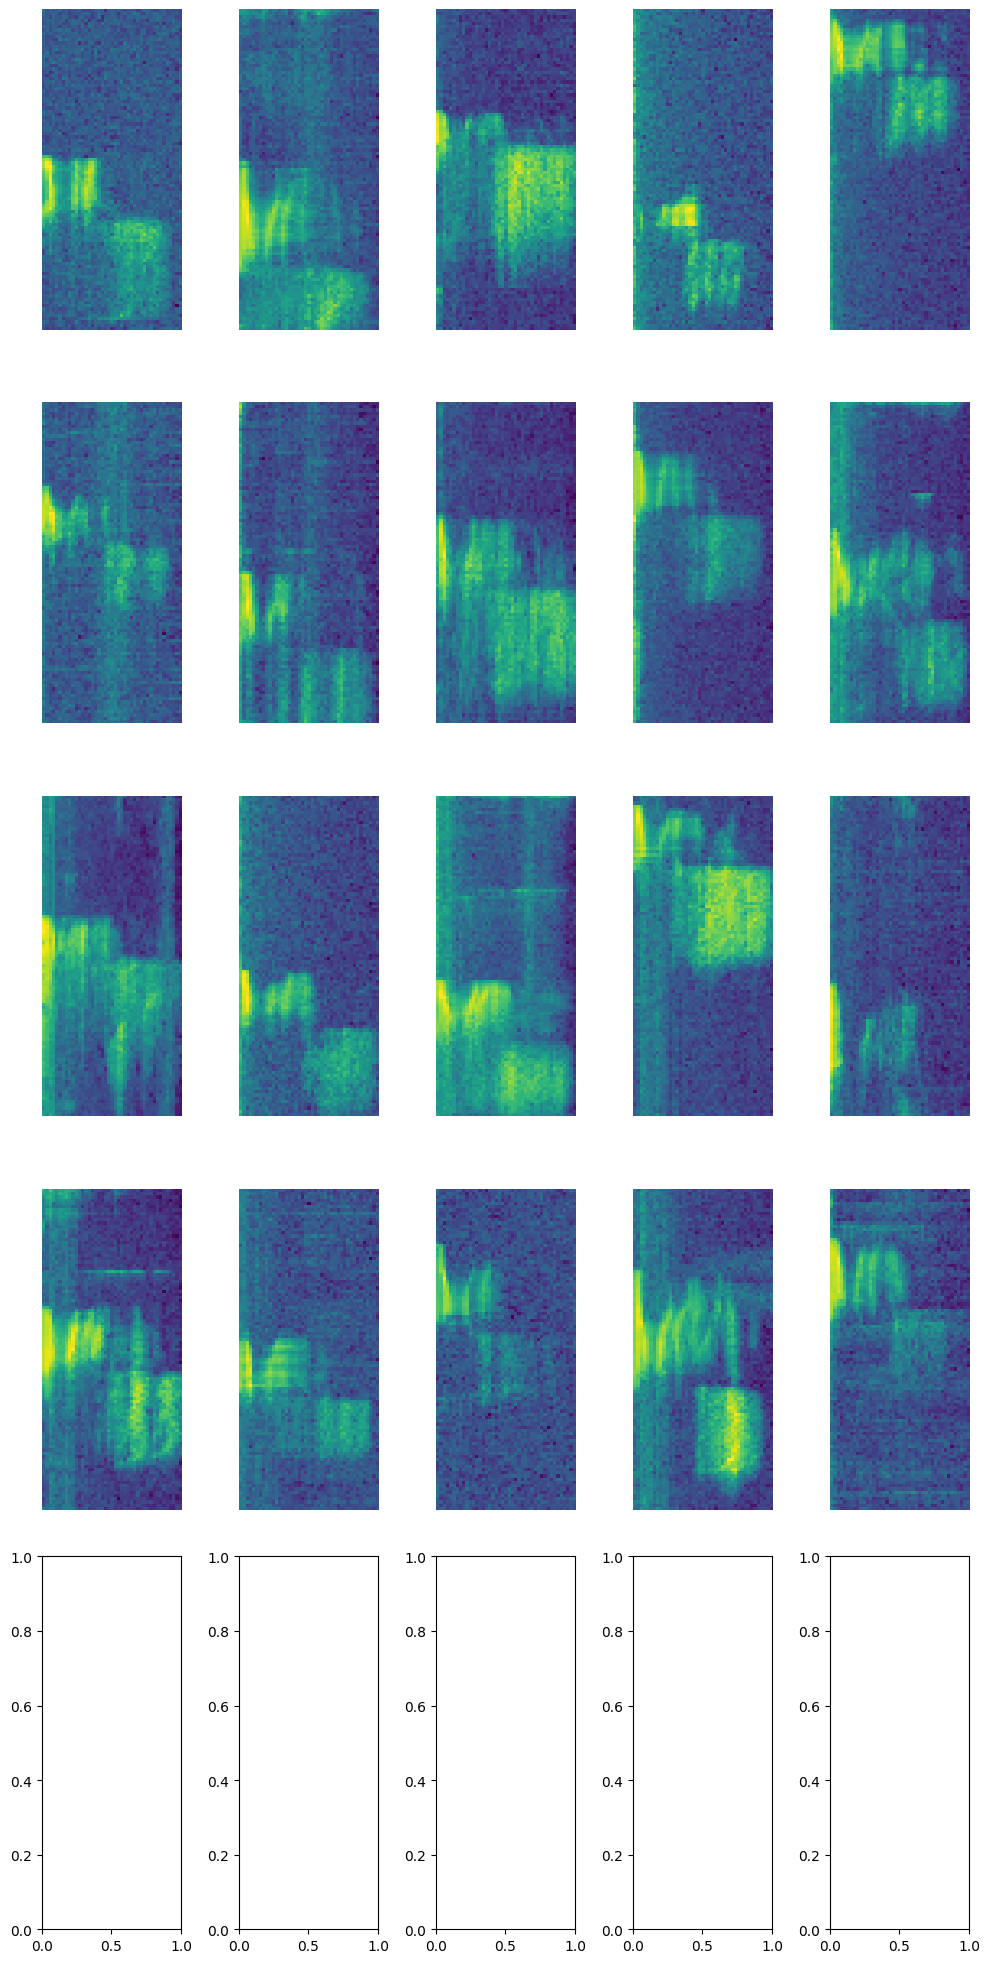

[33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33]


In [36]:
word_index = words.index("yes")

X_marvins = np.array(X_train)[np.array(Y_train) == word_index]
Y_marvins = np.array(Y_train)[np.array(Y_train) == word_index]
plot_images2(X_marvins[:20], IMG_WIDTH, IMG_HEIGHT)
print(Y_marvins[:20])

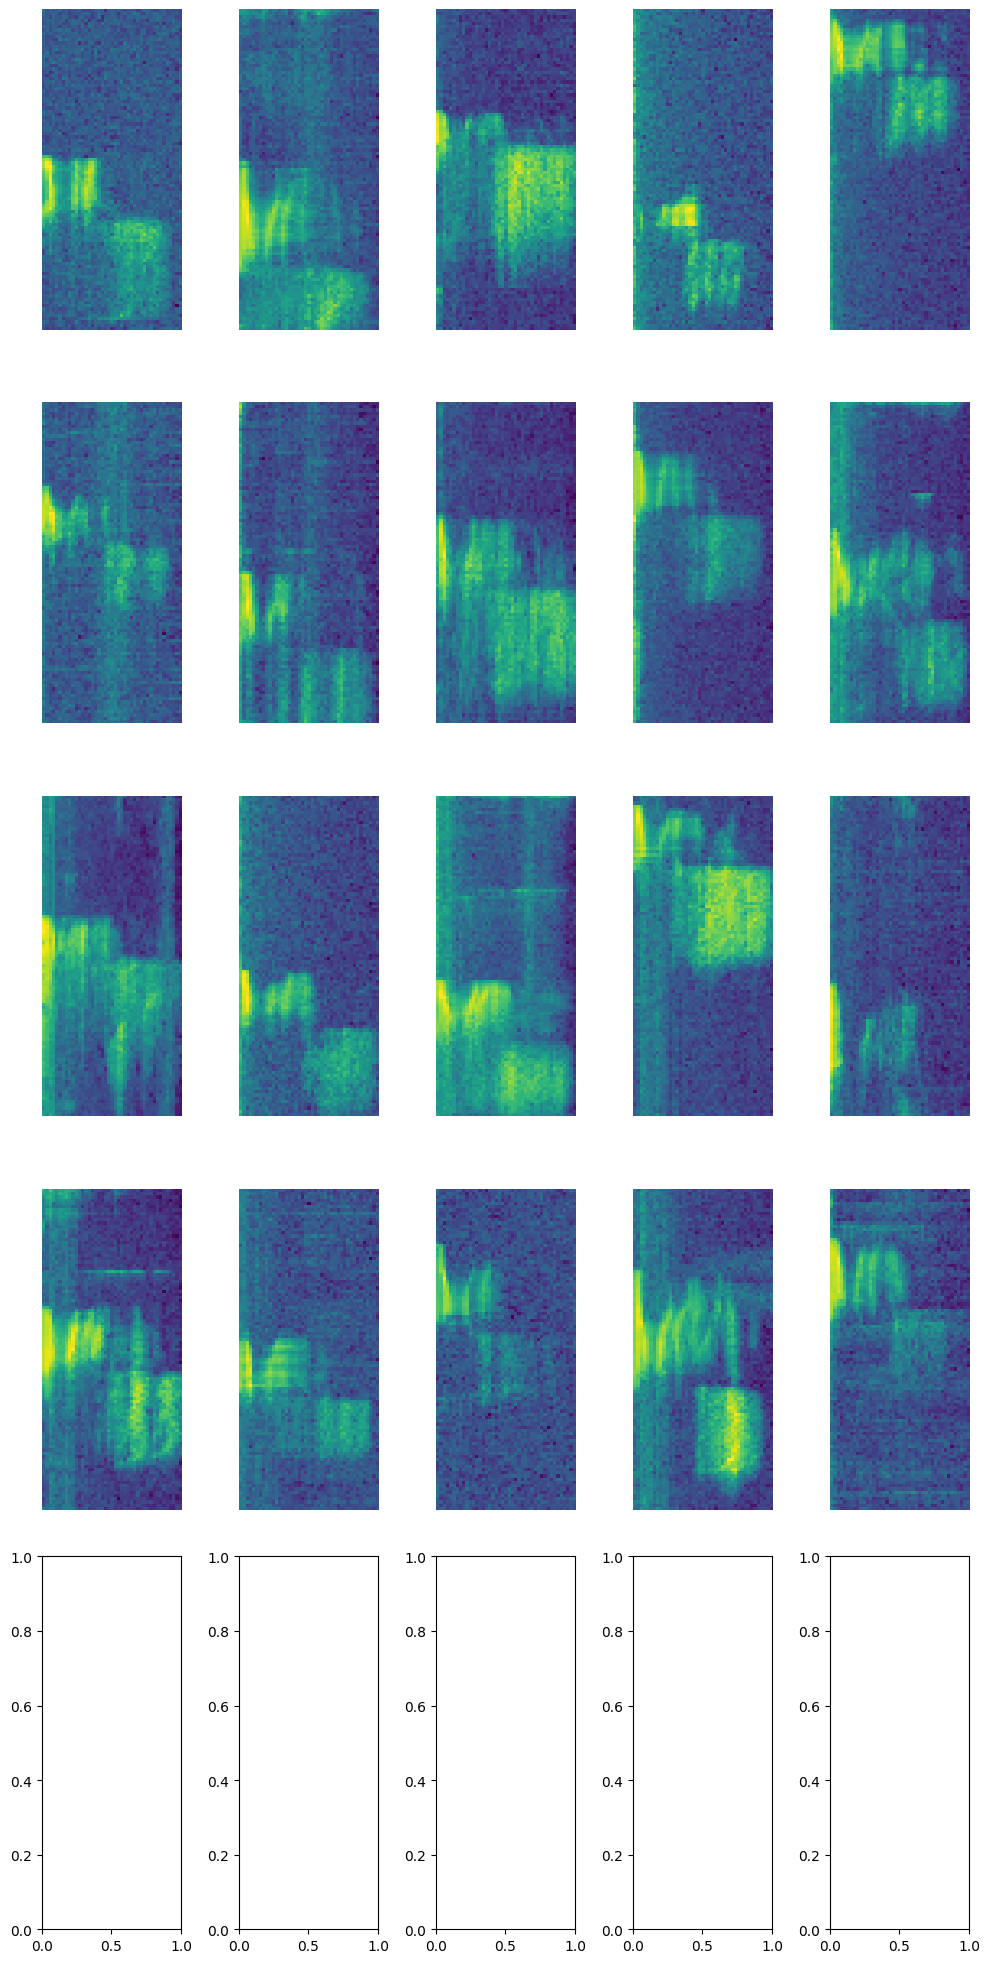

[33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33 33]


In [37]:
word_index = words.index("yes")

X_yes = np.array(X_train)[np.array(Y_train) == word_index]
Y_yes = np.array(Y_train)[np.array(Y_train) == word_index]
plot_images2(X_yes[:20], IMG_WIDTH, IMG_HEIGHT)
print(Y_yes[:20])